###### Fabiha Zeeshan, May 3rd, 2026, ISTA 131, Prof. Thompson
## Brain Cancer Incidence across different races, ages, and sex's in the United States between 2013-2017
#### The data for this project is derived from the WHO Cancer Incidence in Five Continents (CI5) Volume XII website, https://ci5.iarc.fr/ci5-xii/
#### The main questions I wanted to answer using my data were,
> "What is the incidence of brain cancer in young adults and children between the ages of 0-24 in the Asian American population across the USA?"

> "What is the incidence of brain cancer in young adults and children between the ages of 0-24 in Arizona?"

> "What is correlation between brain cancer and race across the USA in young adults and children between the ages of 0-24?" 

### Setup & Data Loading

In [96]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd, numpy as np
from datetime import datetime
import seaborn as sns

cases = pd.read_csv("cancer/cases.csv",usecols=[0,1,2,4,5,6,7,8], index_col = 0, thousands=",", engine='python')
cancer_cases = cases.copy()

### Cleaning & Wrangling

In [97]:
#I Renamed the columns in the csv file (copy) to more readable names
cancer_cases.columns = [el.replace("N0_4","Ages 0-4") for el in cancer_cases.columns]
cancer_cases.columns = [el.replace("N5_9","Ages 5-9") for el in cancer_cases.columns]
cancer_cases.columns = [el.replace("N10_14","Ages 10-14") for el in cancer_cases.columns]
cancer_cases.columns = [el.replace("N15_19","Ages 15-19") for el in cancer_cases.columns]
cancer_cases.columns = [el.replace("N20_24","Ages 20-24") for el in cancer_cases.columns]
cancer_cases.columns = [el.replace("CANCER","Cancer Type") for el in cancer_cases.columns]

#I located specific rows I needed from the dataset. Here, 38400 is the USA cancer registry. This dataset contained information from 
#multiple countries, hence why I needed to filter by USA only. 48 is the classification number for cancer of the brain and nervous system. 
#which is the cancer type that I chose to focus on. 
brain_cancer_cases = cancer_cases.loc[384000010:384008099]
brain_cancer_cases = brain_cancer_cases[brain_cancer_cases['Cancer Type'] == 48]

#Here I have created two seperate dataframes for the male and female cases of brain cancer.
#This is the final filtered data I will be using to create my graphs and DataFrames.  
woman_cases = brain_cancer_cases[brain_cancer_cases['SEX'] == 2].copy()
man_cases = brain_cancer_cases[brain_cancer_cases['SEX'] == 1].copy()

brain_cancer_cases.head()

,SEX,Cancer Type,Ages 0-4,Ages 5-9,Ages 10-14,Ages 15-19,Ages 20-24
REGISTRY,,,,,,,
384000010,1,48,1875,1578,1365,1082,1142
384000010,2,48,1668,1307,1191,892,896
384000030,1,48,286,269,206,162,134
384000030,2,48,261,268,152,155,123
384000099,1,48,2323,1984,1686,1326,1355


###  Analysis & Summary Statistics

In [98]:
#For my first visualization I created two seperate dataframes to hold the data for asian american males and females with brain cancer,
#since these were the two datasets I wanted to compare.
usa_cases_asian = [384001629, 384002529,384004229, 384004329, 384004529, 384004929, 384005229,
                   384005329, 384005529, 384005629, 384006029, 384006229, 384006529, 384006729, 384007129]

#I took the USA cases registry and seperated it by state and race. The registry numbers in usa_cases_asian are the states for 
#which brain cancer data has been provided for Asian Americans. I wanted my series to only include those registry numbers. 
asian_w_cases = woman_cases.loc[384000010:384008099].index
asian_m_cases = man_cases.loc[384000010:384008099].index

w_registry = pd.Series(asian_w_cases)
w_registry = w_registry[w_registry.isin(usa_cases_asian)]
m_registry = pd.Series(asian_m_cases)
m_registry = m_registry[m_registry.isin(usa_cases_asian)]

#My comparison dataframes are ready and seperated by race, sex, state and age. 
asian_wamer_cases = woman_cases.loc[w_registry.values]
asian_mamer_cases = man_cases.loc[m_registry.values]

In [99]:
#For my second visualizaion, I wanted to focus on the Brain Cancer cases for Arizona, by age. I used the same main filtered dataframe, 
#but created a new one filtered by the registry number for the state of Arizona.
usa_cases_az = [384005210, 384005229, 384005230, 384005242]
az_w_cases = woman_cases.loc[384000010:384008099].index
az_m_cases = man_cases.loc[384000010:384008099].index

az_w_registry = pd.Series(az_w_cases)
az_w_registry = az_w_registry[az_w_registry.isin(usa_cases_az)]
az_m_registry = pd.Series(az_m_cases)
az_m_registry = az_m_registry[az_m_registry.isin(usa_cases_az)]

#These are my final comparison dataframes for my second visualization. I used many of same variables and methods that I used for 
#my first visualization to make these dataframes
az_wamer_cases = woman_cases.loc[az_w_registry.values]
az_mamer_cases = man_cases.loc[az_m_registry.values]

In [100]:
#For my third visualization, I wanted to see the correlation between brain cancer cases and race across the USA. For this
#I used the main dataset, which already included all the races by cancer type. 
usa_w_race = woman_cases.copy()
usa_m_race = man_cases.copy()

#I created two dataframes for women and men that were filtered from the previous one by sex and race. 
races = {'10': 'White', '29': 'Asian and Pacific Islander', '30': 'Black', '42':'Native American', '50':'Hispanic White', '60':'Non-Hispanic White'}
usa_w_race.index = [next((v for k, v in races.items() if str(i).endswith(k)), i) for i in usa_w_race.index.astype(str)]
usa_m_race.index = [next((v for k, v in races.items() if str(i).endswith(k)), i) for i in usa_m_race.index.astype(str)]

s_races = ['White','Asian and Pacific Islander','Black','Native American','Hispanic White','Non-Hispanic White']
#My final filtered dataframes only included those rows where the registry number matched the races in the races dictionary.
w_races = usa_w_race[usa_w_race.index.isin(s_races)]
m_races = usa_m_race[usa_m_race.index.isin(s_races)]

### Visualizations

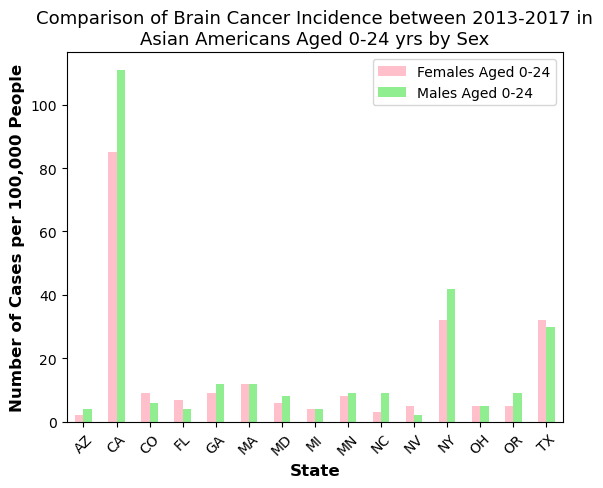

In [101]:
#My first visualization compares the total brain cancer cases for all ages between 0-24 across 16 states for males vs females. 
total_cases = ['Ages 0-4', 'Ages 5-9', 'Ages 10-14', 'Ages 15-19','Ages 20-24']

states = {384001629:'NY', 384002529:'CA',384004229:'MD',
           384004329:'MN', 384004529:'NC', 384004929:'NV',
           384005229:'AZ',384005329:'CO', 384005529:'FL', 
           384005629:'GA',384006029:'MA',384006229:'MI', 
           384006529:'OH',384006729:'OR',384007129:'TX'}

female_total_cases = pd.Series(asian_wamer_cases[total_cases].sum(axis=1)).rename(index=states).sort_values()
male_total_cases = pd.Series(asian_mamer_cases[total_cases].sum(axis=1)).rename(index=states).sort_values()

fig1 = pd.DataFrame({
    'Females Aged 0-24': female_total_cases,
    'Males Aged 0-24': male_total_cases
})
fig1.plot.bar(color=['pink', 'lightgreen'])
plt.title("Comparison of Brain Cancer Incidence between 2013-2017 in\nAsian Americans Aged 0-24 yrs by Sex",fontsize=13)
plt.ylabel("Number of Cases per 100,000 People",fontsize=12,fontweight='bold')
plt.xlabel("State",fontsize=12,fontweight='bold')
plt.xticks(rotation=45) 
plt.show()

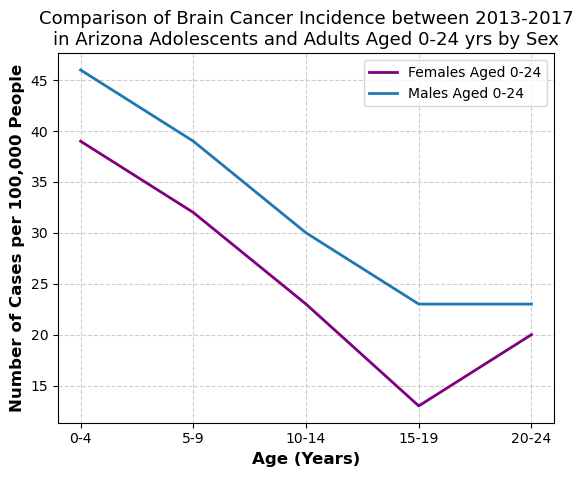

In [102]:
#For my second visualization I summed up the total cases by age as I had done for my previous figure. However this time, I used 
#the ages as the x-axis variable instead of the location. I wanted the x value to be the age, and the y value to be the total cases. 
az_total_cases = ['Ages 0-4', 'Ages 5-9', 'Ages 10-14', 'Ages 15-19','Ages 20-24']
az_ages = ['0-4','5-9','10-14','15-19','20-24']

az_female_total_cases = pd.Series(az_wamer_cases[az_total_cases].sum(axis=0),index=az_total_cases)
az_male_total_cases = pd.Series(az_mamer_cases[az_total_cases].sum(axis=0),index=az_total_cases)

#I realized that this dataset was much smaller than my previous one, so the values overlapped quite a bit. I wasn't able to use a 
#fill-between because of the strong overlap. I also added a grid to this figure for better readability.
plt.plot(range(len(az_total_cases)), az_female_total_cases, 
         label='Females Aged 0-24', color='purple',lw=2)
plt.plot(range(len(az_total_cases)), az_male_total_cases, 
         label='Males Aged 0-24',lw=2)
plt.xticks(ticks=range(len(az_ages)), labels=az_ages)
plt.title("Comparison of Brain Cancer Incidence between 2013-2017\nin Arizona Adolescents and Adults Aged 0-24 yrs by Sex",fontsize=13)
plt.ylabel("Number of Cases per 100,000 People",fontsize=12,fontweight='bold')
plt.xlabel("Age (Years)",fontsize=12,fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

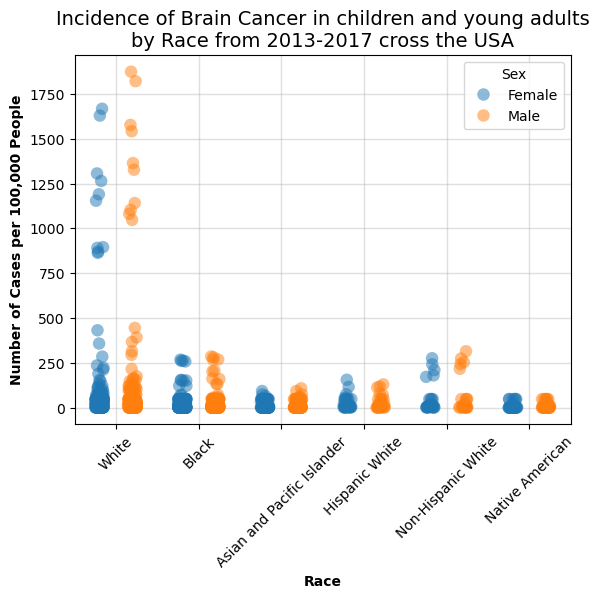

In [106]:
#For my final visualization, I wanted to make a scatter plot and plot each race individually seperated by sex. 
w_melt = w_races.reset_index().melt(id_vars='index', var_name='Age', value_name='Cases')
w_melt['Sex'] = 'Female'
m_melt = m_races.reset_index().melt(id_vars='index', var_name='Age', value_name='Cases')
m_melt['Sex'] = 'Male'

combined_df = pd.concat([w_melt, m_melt])
combined_df.rename(columns={'index': 'Race'}, inplace=True)

sns.stripplot(data=combined_df, x='Race', y='Cases', hue='Sex', jitter=True, dodge=True, alpha=0.5, size=9)
plt.grid(True, linewidth=1, alpha=0.4) 
plt.title('Incidence of Brain Cancer in children and young adults\nby Race from 2013-2017 cross the USA', fontsize=14)
plt.xticks(rotation=45) 
plt.xlabel('Race', fontweight='bold')
plt.ylabel("Number of Cases per 100,000 People", fontweight='bold')
plt.show()